In [1]:
# ENSEMBLE AAPL – BB + MACD

import pandas as pd
import numpy as np
from pathlib import Path
import json
import yfinance as yf
import vectorbt as vbt


# ============================================================
# 1) LOAD DATA
# ============================================================

# DOWNLOAD STOCK DATA FROM 2018 USING YFINANCE

# Configuration - Change these variables as needed
TICKER = 'AAPL'  # Any ticker symbol (e.g., 'AAPL', 'MSFT', 'GOOGL')
START_DATE = '2018-01-01'  # Any start date in YYYY-MM-DD format

# Download data from start date onwards
stock_data = yf.download(TICKER, start=START_DATE, interval='1d')

if not stock_data.empty:
    print(f"Successfully downloaded {len(stock_data)} records for {TICKER} from {START_DATE}")
    print(f"Data range: {stock_data.index.min().date()} to {stock_data.index.max().date()}")
    print("\nFirst 5 rows:")
    print(stock_data.head())
else:
    print(f"Failed to download {TICKER} data from yfinance")

# Display the downloaded data
stock_data



C:\Users\clanf\AppData\Local\Temp\ipykernel_22964\2662486890.py:22: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed

Successfully downloaded 2004 records for AAPL from 2018-01-01
Data range: 2018-01-02 to 2025-12-19

First 5 rows:
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2018-01-02  40.341885  40.351254  39.639309  39.850084  102223600
2018-01-03  40.334877  40.878204  40.271648  40.405135  118071600
2018-01-04  40.522221  40.625266  40.299739  40.407465   89738400
2018-01-05  40.983582  41.070231  40.526908  40.618243   94640000
2018-01-08  40.831348  41.126429  40.732985  40.831348   82271200


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2018-01-02,40.341885,40.351254,39.639309,39.850084,102223600
2018-01-03,40.334877,40.878204,40.271648,40.405135,118071600
2018-01-04,40.522221,40.625266,40.299739,40.407465,89738400
2018-01-05,40.983582,41.070231,40.526908,40.618243,94640000
2018-01-08,40.831348,41.126429,40.732985,40.831348,82271200
...,...,...,...,...,...
2025-12-15,274.109985,280.149994,272.839996,280.149994,50409100
2025-12-16,274.609985,275.500000,271.790009,272.820007,37648600


In [2]:
import json
import os
from pathlib import Path

# ============================================================
# 2) ROBUST PARAMETER LOADING (SMART PATH FINDER)
# ============================================================

# Definiamo il nome della cartella target dove risiedono i JSON
TARGET_FOLDER = Path("data") / "single_indicator" / "aapl"

# File specifici da cercare
FILENAME_BB = "best_params_bb_aapl.json"
FILENAME_MACD = "best_params_macd_aapl.json"

def get_smart_path(filename):
    """
    Cerca il file in diverse posizioni relative per gestire 
    il fatto che il notebook possa essere stato spostato.
    """
    # 1. Dove sono io adesso? (Cartella del notebook)
    current_dir = Path.cwd()
    
    # Lista di possibili percorsi completi da tentare
    possible_paths = [
        # Tentativo A: La cartella 'data' è nella directory superiore (caso ftmo_challenge)
        current_dir.parent / TARGET_FOLDER / filename,
        
        # Tentativo B: La cartella 'data' è nella directory corrente (caso vecchio)
        current_dir / TARGET_FOLDER / filename,
        
        # Tentativo C: Percorso assoluto (se sei su root del progetto)
        Path(filename) # Cerca direttamente il file se fosse nella stessa cartella
    ]
    
    for p in possible_paths:
        if p.exists():
            return p
            
    return None

# --- FUNZIONE DI CARICAMENTO ---
def load_params_safe(filename, default_params, strategy_name):
    found_path = get_smart_path(filename)
    
    if found_path:
        try:
            with open(found_path, "r") as f:
                params = json.load(f)
            print(f"✅ {strategy_name}: Parametri caricati da: {found_path}")
            return params
        except json.JSONDecodeError:
            print(f"⚠️ {strategy_name}: File trovato ma corrotto. Uso default.")
    else:
        print(f"⚠️ {strategy_name}: File '{filename}' NON TROVATO.")
        print(f"   -> Ho cercato 'data' sia nella cartella corrente che in quella superiore.")
        print(f"   -> Uso parametri DEFAULT per non bloccare il codice.")
        
    return default_params

# --- ESECUZIONE ---

# Parametri di default (Emergenza)
default_bb = {'window': 20, 'window_dev': 2.0}
default_macd = {'fast_window': 12, 'slow_window': 26, 'signal_window': 9}

# Caricamento Effettivo
best_bb_aapl = load_params_safe(FILENAME_BB, default_bb, "Bollinger")
best_macd_aapl = load_params_safe(FILENAME_MACD, default_macd, "MACD")

print("-" * 60)
print("READY FOR ENSEMBLE CONSTRUCTION")
print(f"Attuale configurazione BB: {best_bb_aapl}")
print(f"Attuale configurazione MACD: {best_macd_aapl}")
print("-" * 60)

✅ Bollinger: Parametri caricati da: c:\Users\clanf\OneDrive\Desktop\algo trading\data\single_indicator\aapl\best_params_bb_aapl.json
✅ MACD: Parametri caricati da: c:\Users\clanf\OneDrive\Desktop\algo trading\data\single_indicator\aapl\best_params_macd_aapl.json
------------------------------------------------------------
READY FOR ENSEMBLE CONSTRUCTION
Attuale configurazione BB: {'bb_window': 10, 'bb_sigma': 2.3}
Attuale configurazione MACD: {'fast_period': 36, 'slow_period': 52, 'signal_period': 29}
------------------------------------------------------------


In [3]:
import pandas as pd
import numpy as np
import vectorbt as vbt

# ============================================================
# 3) STRATEGY FUNCTIONS (MACD + BOLLINGER) with 1 / 0 / -1 signals
# ============================================================

def generate_bb_signals(price, window, sigma):
    """
    Bollinger Bands Mean Reversion signals on 'price':
    +1 = entry long (Price < Lower Band -> Panic Zone)
    -1 = exit       (Price > Middle Band -> Recovery Zone)
     0 = neutral
    """
    # 1. Calcolo Bollinger (vettorizzato)
    bb = vbt.BBANDS.run(price, window=window, alpha=sigma)

    # 2. Logica Mean Reversion (Coerente con la Grid Search)
    # Entry: Prezzo SOTTO la banda inferiore
    # Exit:  Prezzo SOPRA la media mobile (Middle Band)
    entries_raw = price < bb.lower
    exits_raw   = price > bb.middle

    # 3. Shift per evitare Lookahead Bias (entriamo all'apertura successiva)
    entries = entries_raw.shift(1).fillna(False).astype(bool)
    exits   = exits_raw.shift(1).fillna(False).astype(bool)

    # 4. Conversione in segnale numerico (+1, -1, 0)
    # Nota: A differenza del MACD che è un "impulso" (crossover), 
    # qui il segnale +1 persiste finché siamo in zona panico. 
    # Questo è ottimo per il voto: rinforza la convinzione di entrare.
    signal = pd.Series(0, index=price.index)
    signal[entries] = 1
    signal[exits] = -1

    return signal


def generate_macd_signals(price, fast_period, slow_period, signal_period):
    """
    MACD crossover signals on 'price':
    +1 = entry long (MACD cross sopra signal)
    -1 = exit       (MACD cross sotto signal)
     0 = neutral
    """
    # MACD lines costruiti via EMA
    macd_fast = vbt.MA.run(price, fast_period, ewm=True).ma
    macd_slow = vbt.MA.run(price, slow_period, ewm=True).ma
    macd = macd_fast - macd_slow
    macd_signal = vbt.MA.run(macd, signal_period, ewm=True).ma

    # Crossover Logic (Impulsiva)
    cross_up = (macd > macd_signal) & (macd.shift(1) <= macd_signal.shift(1))
    cross_down = (macd < macd_signal) & (macd.shift(1) >= macd_signal.shift(1))

    # Shift per evitare lookahead
    entries = cross_up.shift(1).fillna(False).astype(bool)
    exits = cross_down.shift(1).fillna(False).astype(bool)

    signal = pd.Series(0, index=price.index)
    signal[entries] = 1
    signal[exits] = -1

    return signal

print("Strategy functions defined: generate_bb_signals, generate_macd_signals")

Strategy functions defined: generate_bb_signals, generate_macd_signals


In [4]:
import yfinance as yf
import pandas as pd

# ============================================================
# 3.5) LOAD DATA INTO df (Ensemble Data Loading)
# ============================================================

# Parameters (Targeting Apple as requested)
TICKER = "AAPL"
START_DATE = "2018-01-01" # Allineato con il periodo usato nel training (consigliato)
END_DATE = None  # latest

print(f"Downloading data for {TICKER}...")
stock_data = yf.download(TICKER, start=START_DATE, end=END_DATE)

if stock_data.empty:
    raise ValueError("Downloaded data is empty. Check TICKER or internet connection.")

# Create df copying the structure needed
df = stock_data.copy()

# Handling MultiIndex columns (Fix per yfinance recent updates)
if isinstance(df.columns, pd.MultiIndex):
    # Prova a estrarre la colonna Close per il ticker specifico
    try:
        df["close"] = df[("Close", TICKER)]
    except KeyError:
        # Fallback: prende la prima colonna che si chiama 'Close'
        df["close"] = df.xs('Close', level=0, axis=1).iloc[:, 0]
else:
    df["close"] = df["Close"]

# Ensure close is float
df["close"] = df["close"].astype(float)

# Optional: return columns if used elsewhere
df["returns"] = df["close"].pct_change().fillna(0)

# Clean dataframe
df = df.dropna().copy()

print(f"Data loaded for {TICKER} into df → shape:", df.shape)
print(df.head())

C:\Users\clanf\AppData\Local\Temp\ipykernel_22964\4187260467.py:14: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed

Data loaded for AAPL into df → shape: (2004, 7)
Price           Close       High        Low       Open     Volume      close  \
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL              
Date                                                                           
2018-01-02  40.341881  40.351250  39.639305  39.850080  102223600  40.341881   
2018-01-03  40.334869  40.878196  40.271640  40.405128  118071600  40.334869   
2018-01-04  40.522209  40.625254  40.299728  40.407454   89738400  40.522209   
2018-01-05  40.983570  41.070220  40.526897  40.618231   94640000  40.983570   
2018-01-08  40.831341  41.126421  40.732977  40.831341   82271200  40.831341   

Price        returns  
Ticker                
Date                  
2018-01-02  0.000000  
2018-01-03 -0.000174  
2018-01-04  0.004645  
2018-01-05  0.011385  
2018-01-08 -0.003714  


In [5]:
# ============================================================
# 4) REBUILD SINGLE-INDICATOR SIGNALS USING BEST PARAMS
# ============================================================

# Assumo che df esista già e che contenga almeno la colonna 'close'
if "df" not in globals():
    raise ValueError("DataFrame 'df' not found. Make sure you loaded your data into df first.")

if "close" not in df.columns:
    raise ValueError("Column 'close' not found in df. Make sure df has a 'close' price column.")

price = df["close"].copy()

# --- 1. Generazione Segnali Bollinger (Mean Reversion) ---
# Usiamo le chiavi 'bb_window' e 'bb_sigma' salvate nel JSON
signal_bb = generate_bb_signals(
    price=price,
    window=best_bb_aapl["bb_window"],
    sigma=best_bb_aapl["bb_sigma"]
)

# --- 2. Generazione Segnali MACD (Trend Following) ---
# Gestione robusta delle chiavi (supporta sia 'fast_window' che 'fast_period' per retrocompatibilità)
fast_p = best_macd_aapl.get("fast_window", best_macd_aapl.get("fast_period", 12))
slow_p = best_macd_aapl.get("slow_window", best_macd_aapl.get("slow_period", 26))
sign_p = best_macd_aapl.get("signal_window", best_macd_aapl.get("signal_period", 9))

signal_macd = generate_macd_signals(
    price=price,
    fast_period=fast_p,
    slow_period=slow_p,
    signal_period=sign_p
)

# --- 3. Creazione DataFrame Segnali ---
signals_df = pd.DataFrame({
    "price": price,
    "signal_bb": signal_bb,     # +1 Panic Buy, -1 Mean Rev Exit
    "signal_macd": signal_macd, # +1 Trend Start, -1 Trend End
})

print("Signals generated. Preview:")
print(signals_df.tail(10))

Signals generated. Preview:
                 price  signal_bb  signal_macd
Date                                          
2025-12-08  277.890015          0            0
2025-12-09  277.179993          0            0
2025-12-10  278.779999          0           -1
2025-12-11  278.029999          0            0
2025-12-12  278.279999          0            0
2025-12-15  274.109985          0            0
2025-12-16  274.609985          0            0
2025-12-17  271.839996          0            0
2025-12-18  272.190002          0            0
2025-12-19  273.670013          0            0


C:\Users\clanf\AppData\Local\Temp\ipykernel_22964\3748414114.py:26: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

C:\Users\clanf\AppData\Local\Temp\ipykernel_22964\3748414114.py:27: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

C:\Users\clanf\AppData\Local\Temp\ipykernel_22964\3748414114.py:58: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

In [6]:
# ============================================================
# 5) ENSEMBLE LOGIC: STATEFUL HYBRID (CORRECTED)
# ============================================================

def build_ensemble_position_stateful(signal_bb, signal_macd):
    """
    Costruisce la posizione usando una logica a STATI separati.
    Mantiene in memoria quale strategia è "attiva".
    
    Regole:
    - MACD: Si attiva su +1 (CrossUp), si disattiva SOLO su -1 (CrossDown).
    - BB:   Si attiva su +1 (Panic), si disattiva su -1 (Mean Reversion).
    
    Posizione Finale:
    - 1 (Long) se (MACD_Active == True) OR (BB_Active == True)
    - 0 (Flat) altrimenti.
    
    Vantaggio: 
    L'uscita anticipata delle BB (tocco della media) NON uccide il trend del MACD.
    L'uscita del trend del MACD NON impedisce un trade di rimbalzo delle BB.
    """
    
    s_bb = signal_bb.fillna(0).astype(int).values
    s_macd = signal_macd.fillna(0).astype(int).values
    
    positions = []
    
    # Stati iniziali (Flat)
    macd_active = False
    bb_active = False
    
    for bb_sig, macd_sig in zip(s_bb, s_macd):
        
        # --- 1. AGGIORNAMENTO STATO MACD (Trend Engine) ---
        if macd_sig == 1:
            macd_active = True   # Inizia Trend
        elif macd_sig == -1:
            macd_active = False  # Fine Trend
            
        # --- 2. AGGIORNAMENTO STATO BB (Scalp Engine) ---
        if bb_sig == 1:
            bb_active = True     # Inizia Scalp (Panic)
        elif bb_sig == -1:
            bb_active = False    # Fine Scalp (Target Preso)
            
        # --- 3. DECISIONE FINALE (Logica OR) ---
        # Stiamo dentro se c'è un Trend OPPURE se stiamo scalpo un dip
        if macd_active or bb_active:
            positions.append(1)
        else:
            positions.append(0)
            
    return pd.Series(positions, index=signal_bb.index, name="position_ensemble")

# Costruzione della posizione ensemble corretta
position_ensemble = build_ensemble_position_stateful(
    signals_df["signal_bb"],
    signals_df["signal_macd"]
)

signals_df["position_ensemble"] = position_ensemble

# Debug visivo: Vediamo se ci sono periodi lunghi di '1' (Trend)
print("Position Distribution:")
print(signals_df["position_ensemble"].value_counts())
print("\nPreview:")
print(signals_df[["price", "signal_bb", "signal_macd", "position_ensemble"]].tail(15))

Position Distribution:
position_ensemble
1    1167
0     837
Name: count, dtype: int64

Preview:
                 price  signal_bb  signal_macd  position_ensemble
Date                                                             
2025-12-01  283.100006         -1            0                  0
2025-12-02  286.190002         -1            1                  1
2025-12-03  284.149994         -1            0                  1
2025-12-04  280.700012         -1            0                  1
2025-12-05  278.779999         -1            0                  1
2025-12-08  277.890015          0            0                  1
2025-12-09  277.179993          0            0                  1
2025-12-10  278.779999          0           -1                  0
2025-12-11  278.029999          0            0                  0
2025-12-12  278.279999          0            0                  0
2025-12-15  274.109985          0            0                  0
2025-12-16  274.609985          0            

In [7]:
import numpy as np
import pandas as pd
import vectorbt as vbt

# ============================================================
# 6) BACKTEST ENSEMBLE STRATEGY (MACD + BB)
# ============================================================

# Deriviamo entries / exits dalla posizione 0/1 calcolata nello step precedente
# position_ensemble è già "shiftata" (contiene la decisione per il giorno corrente)
pos = position_ensemble.fillna(0).astype(int)

# Logica di transizione: Entriamo quando passiamo da 0 a 1, Usciamo da 1 a 0
entries = (pos.shift(1).fillna(0) == 0) & (pos == 1)
exits   = (pos.shift(1).fillna(0) == 1) & (pos == 0)

# Portafoglio ensemble su tutto il price
portfolio = vbt.Portfolio.from_signals(
    close=price,
    entries=entries,
    exits=exits,
    init_cash=100_000,
    fees=0.0005,
    slippage=0.0005,
    freq='D',
    sl_stop=0.05  # <--- STOP LOSS AGGIUNTO (Critico per la robustezza vista su BB)
)

# Metriche principali
total_return = float(portfolio.total_return())
annual_return = float(portfolio.annualized_return())
volatility = float(portfolio.annualized_volatility())
sharpe_ratio = float(portfolio.sharpe_ratio())
max_drawdown = float(portfolio.max_drawdown())
calmar_ratio = float(portfolio.calmar_ratio())

# Info trades
trades = portfolio.trades
total_trades = int(len(trades))

win_rate = np.nan
profit_factor = np.nan
expectancy = 0.0

if total_trades > 0:
    tr = trades.returns.values if hasattr(trades.returns, "values") else np.array(trades.returns)
    if tr.size > 0:
        pos_ret = tr[tr > 0]
        neg_ret = tr[tr < 0]
        
        win_rate = (len(pos_ret) / len(tr)) * 100.0
        
        gains = pos_ret.sum() if len(pos_ret) else 0.0
        losses = abs(neg_ret.sum()) if len(neg_ret) else 0.0
        
        profit_factor = (gains / losses) if losses > 0 else np.inf
        expectancy = float(tr.mean())

# Costruiamo un dict in stile grid_search_results
ensemble_results = {
    "total_return": total_return,
    "annual_return": annual_return,
    "volatility": volatility,
    "sharpe_ratio": sharpe_ratio,
    "max_drawdown": max_drawdown,
    "calmar_ratio": calmar_ratio,
    "total_trades": total_trades,
    "win_rate": float(win_rate) if not np.isnan(win_rate) else np.nan,
    "profit_factor": float(profit_factor) if not np.isnan(profit_factor) else np.nan,
    "expectancy": expectancy
}

print("="*40)
print("ENSEMBLE STRATEGY RESULTS (AAPL)")
print("="*40)
print(f"Total Return:      {ensemble_results['total_return']:.2%}")
print(f"Annualized Return: {ensemble_results['annual_return']:.2%}")
print(f"Sharpe Ratio:      {ensemble_results['sharpe_ratio']:.3f}")
print(f"Max Drawdown:      {ensemble_results['max_drawdown']:.2%}")
print(f"Volatility:        {ensemble_results['volatility']:.2%}")
print(f"Calmar Ratio:      {ensemble_results['calmar_ratio']:.3f}")
print("-" * 40)
print(f"Total Trades:      {ensemble_results['total_trades']}")
print(f"Win Rate:          {ensemble_results['win_rate']:.1f}%")
print(f"Profit Factor:     {ensemble_results['profit_factor']:.2f}")
print("="*40)

ENSEMBLE STRATEGY RESULTS (AAPL)
Total Return:      679.54%
Annualized Return: 45.36%
Sharpe Ratio:      1.783
Max Drawdown:      -26.81%
Volatility:        22.39%
Calmar Ratio:      1.692
----------------------------------------
Total Trades:      35
Win Rate:          62.9%
Profit Factor:     5.35


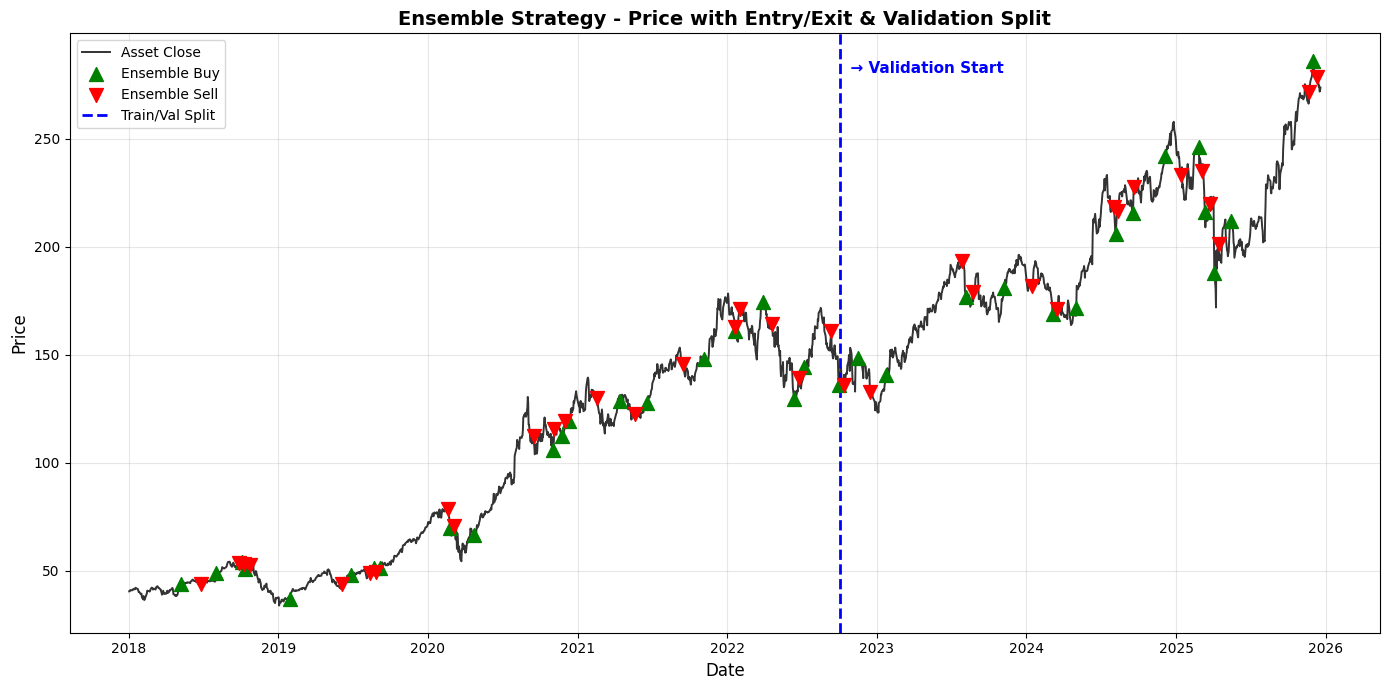

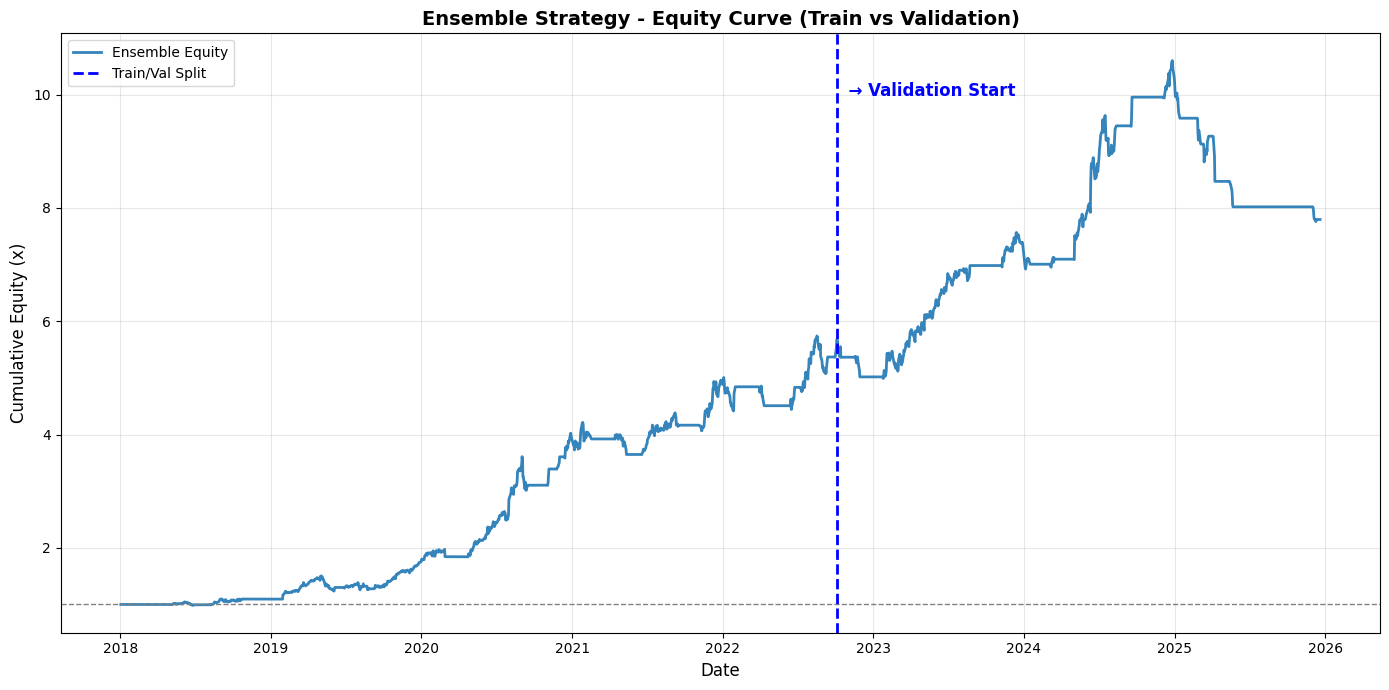

Trade-by-Trade Stats (Ensemble):
   Total trades     : 35
   Win rate         : 62.86%
   Avg win %        : 13.87%
   Avg loss %       : -4.39%
   Avg trade %      : 7.09%


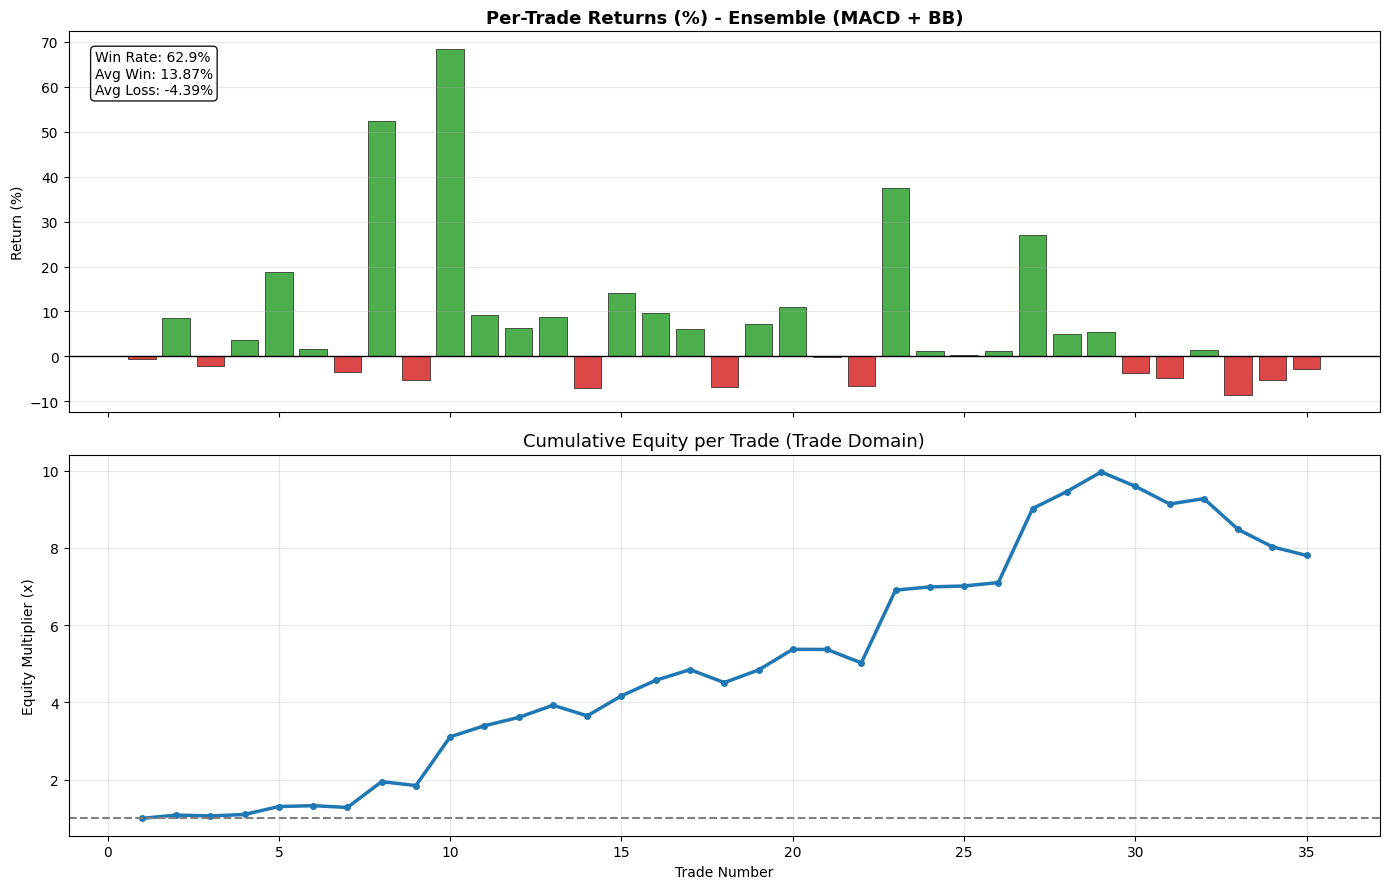

✅ Visualization Complete with Train/Validation Split Line.


In [8]:
# ============================================================
# 6.5) VISUALS: PRICE, EQUITY CURVE, TRADE-BY-TRADE RETURNS (FINAL VERSION)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import vectorbt as vbt

# --- CONFIGURAZIONE SPLIT ---
SPLIT_DATE = '2022-10-04'  # La data che separa il Training dal Validation

# Controlli base
if "signals_df" not in globals():
    raise ValueError("signals_df not found. Run the ensemble signal cells first.")

if "position_ensemble" not in signals_df.columns:
    raise ValueError("'position_ensemble' not found in signals_df. Build ensemble position first.")

price = signals_df["price"].astype(float)
pos = signals_df["position_ensemble"].fillna(0).astype(int)

# Rebuild entries / exits from position (Logica: 0->1 Entry, 1->0 Exit)
entries_full = (pos.shift(1).fillna(0) == 0) & (pos == 1)
exits_full   = (pos.shift(1).fillna(0) == 1) & (pos == 0)

# Frequenza default se non definita
if "FREQ" not in globals():
    FREQ = "1D"

# Portfolio full-sample (Alias o Ricreazione)
# Se 'portfolio' esiste dallo step precedente, usiamo quello.
if "portfolio" in globals():
    pf_full = portfolio
else:
    # Se dobbiamo ricrearlo, ricordiamoci lo STOP LOSS!
    pf_full = vbt.Portfolio.from_signals(
        close=price,
        entries=entries_full,
        exits=exits_full,
        init_cash=100_000,
        fees=0.0005,
        slippage=0.0005,
        freq=FREQ,
        sl_stop=0.05 # <--- Importante per coerenza
    )

# ============================================================
# 1) PREZZO + ENTRY / EXIT + SPLIT LINE
# ============================================================

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(price.index, price.values, label="Asset Close", linewidth=1.4, alpha=0.8, color='black')

# Estrazione date segnali
buy_idx = price.index[entries_full]
sell_idx = price.index[exits_full]

if len(buy_idx) > 0:
    ax.scatter(buy_idx, price.loc[buy_idx].values,
               marker="^", s=100, label="Ensemble Buy", color="green", zorder=5)
if len(sell_idx) > 0:
    ax.scatter(sell_idx, price.loc[sell_idx].values,
               marker="v", s=100, label="Ensemble Sell", color="red", zorder=5)

# --- VISUALIZZAZIONE SPLIT TRAIN/VAL ---
split_dt = pd.Timestamp(SPLIT_DATE)
if split_dt >= price.index.min() and split_dt <= price.index.max():
    ax.axvline(split_dt, color='blue', linestyle='--', linewidth=2, label='Train/Val Split')
    # Etichetta in alto a destra della linea
    ax.text(split_dt, price.max(), '  \u2192 Validation Start', 
            color='blue', ha='left', va='top', fontsize=11, fontweight='bold')

ax.set_title("Ensemble Strategy - Price with Entry/Exit & Validation Split",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Price", fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

# ============================================================
# 2) EQUITY CURVE FULL SAMPLE + SPLIT LINE
# ============================================================

eq_full = (1 + pf_full.returns()).cumprod()

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(eq_full.index, eq_full.values, linewidth=2, alpha=0.9, label="Ensemble Equity", color='#1f77b4')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)

# --- VISUALIZZAZIONE SPLIT TRAIN/VAL ---
if split_dt >= eq_full.index.min() and split_dt <= eq_full.index.max():
    ax.axvline(split_dt, color='blue', linestyle='--', linewidth=2, label='Train/Val Split')
    # Etichetta posizionata dinamicamente vicino al massimo locale dell'equity
    y_pos = eq_full.max() * 0.95
    ax.text(split_dt, y_pos, '  \u2192 Validation Start', 
            color='blue', ha='left', va='center', fontsize=12, fontweight='bold')

ax.set_title("Ensemble Strategy - Equity Curve (Train vs Validation)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Cumulative Equity (x)", fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

# ============================================================
# 3) TRADE-BY-TRADE RETURNS + EQUITY PER TRADE
# ============================================================

trades = pf_full.trades
# Gestione robusta dei returns (array numpy)
trade_returns = trades.returns.values if hasattr(trades.returns, "values") else np.asarray(trades.returns)
trade_returns = np.asarray(trade_returns).ravel()

if trade_returns.size == 0:
    print("No trades to plot for trade-by-trade analysis.")
else:
    winning_trades = trade_returns[trade_returns > 0]
    losing_trades = trade_returns[trade_returns < 0]

    total_trades = len(trade_returns)
    win_count = len(winning_trades)
    loss_count = len(losing_trades)
    
    win_rate = (win_count / total_trades * 100) if total_trades > 0 else 0.0

    avg_win_pct = (winning_trades.mean() * 100) if len(winning_trades) > 0 else 0.0
    avg_loss_pct = (losing_trades.mean() * 100) if len(losing_trades) > 0 else 0.0
    avg_trade_pct = (trade_returns.mean() * 100) if len(trade_returns) > 0 else 0.0

    # Cumulative equity per trade (starting from 1)
    equity_per_trade = np.cumprod(1 + trade_returns)

    print("Trade-by-Trade Stats (Ensemble):")
    print(f"   Total trades     : {total_trades}")
    print(f"   Win rate         : {win_rate:.2f}%")
    print(f"   Avg win %        : {avg_win_pct:.2f}%")
    print(f"   Avg loss %       : {avg_loss_pct:.2f}%")
    print(f"   Avg trade %      : {avg_trade_pct:.2f}%")

    x = np.arange(1, total_trades + 1)

    fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

    # Bar dei returns trade-by-trade
    colors = ["#2ca02c" if r > 0 else "#d62728" for r in trade_returns]
    axes[0].bar(x, trade_returns * 100, color=colors, alpha=0.85, width=0.8, edgecolor='black', linewidth=0.5)
    axes[0].axhline(0, color="black", linewidth=1)
    axes[0].set_title("Per-Trade Returns (%) - Ensemble (MACD + BB)", fontsize=13, fontweight="bold")
    axes[0].set_ylabel("Return (%)")
    axes[0].grid(True, alpha=0.3, axis='y')
    
    # Stats Box
    stats_text = (f'Win Rate: {win_rate:.1f}%\nAvg Win: {avg_win_pct:.2f}%\nAvg Loss: {avg_loss_pct:.2f}%')
    axes[0].text(0.02, 0.95, stats_text, transform=axes[0].transAxes, 
                 fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

    # Equity cumulata per trade
    axes[1].plot(x, equity_per_trade, linewidth=2.5, color='#1f77b4', marker='o', markersize=4)
    axes[1].axhline(1.0, color='gray', linestyle='--')
    axes[1].set_title("Cumulative Equity per Trade (Trade Domain)", fontsize=13)
    axes[1].set_xlabel("Trade Number")
    axes[1].set_ylabel("Equity Multiplier (x)")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("✅ Visualization Complete with Train/Validation Split Line.")

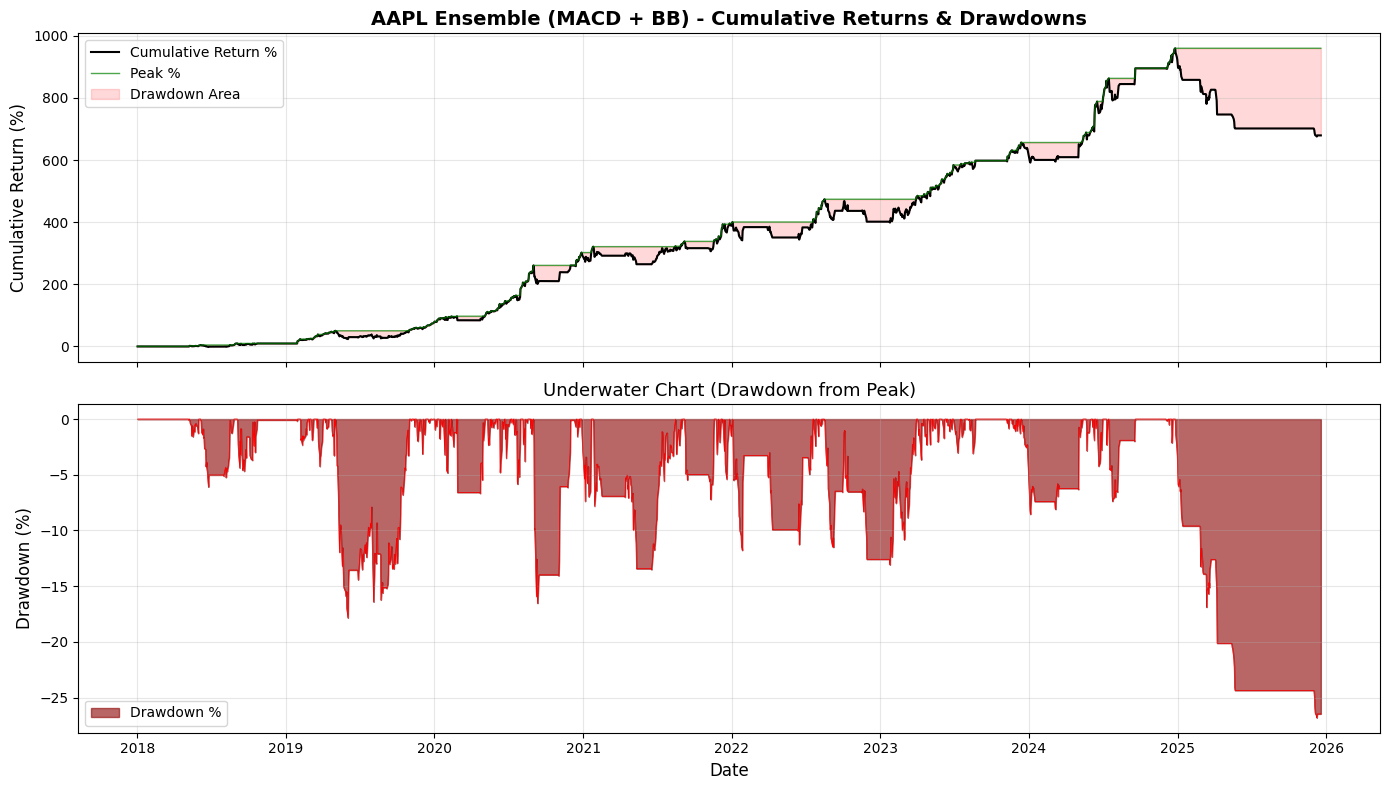

✅ Drawdown analysis (equity + underwater) complete for Ensemble AAPL.


In [9]:
# ============================================================
# 6.5.2) DRAWDOWNS: CUMULATIVE RETURNS + UNDERWATER CHART
# ============================================================

import matplotlib.pyplot as plt
import vectorbt as vbt
import numpy as np

# Controlli base
if "signals_df" not in globals():
    raise ValueError("signals_df not found. Run the ensemble signal cells first.")

if "position_ensemble" not in signals_df.columns:
    raise ValueError("'position_ensemble' not found in signals_df. Build ensemble position first.")

price = signals_df["price"].astype(float)
pos = signals_df["position_ensemble"].fillna(0).astype(int)

# Ricostruisci entries / exits (0 -> 1 = entry, 1 -> 0 = exit)
entries_full = (pos.shift(1).fillna(0) == 0) & (pos == 1)
exits_full   = (pos.shift(1).fillna(0) == 1) & (pos == 0)

# Frequenza default se non definita
if "FREQ" not in globals():
    FREQ = "1D"

# Usa pf_full se già esiste (dallo step 6.5), altrimenti crealo con STOP LOSS
try:
    pf_dd = pf_full
except NameError:
    pf_dd = vbt.Portfolio.from_signals(
        close=price,
        entries=entries_full,
        exits=exits_full,
        init_cash=100_000,
        fees=0.0005,
        slippage=0.0005,
        freq=FREQ,
        sl_stop=0.05 # <--- Stop Loss mantenuto per coerenza
    )

# Serie di rendimenti
ret = pf_dd.returns()

if ret.isna().all():
    print("⚠️ Not enough data to compute returns/drawdowns.")
else:
    # Equity, peak, drawdown
    eq = (1 + ret).cumprod()
    peak = eq.cummax()
    dd = (eq - peak) / peak  # valori negativi (drawdown)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # === 1) Cumulative Returns & Drawdown Area ===
    ax1.plot(eq.index, (eq - 1) * 100,
             color='black', linewidth=1.5, label='Cumulative Return %')
    ax1.plot(peak.index, (peak - 1) * 100,
             color='green', linewidth=1.0, alpha=0.7, label='Peak %')

    ax1.fill_between(
        eq.index,
        (eq - 1) * 100,
        (peak - 1) * 100,
        color='red',
        alpha=0.15,
        label='Drawdown Area'
    )

    ax1.set_title("AAPL Ensemble (MACD + BB) - Cumulative Returns & Drawdowns",
                  fontsize=14, fontweight='bold')
    ax1.set_ylabel("Cumulative Return (%)", fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper left')

    # === 2) Underwater Chart (Drawdown %) ===
    ax2.fill_between(dd.index, dd * 100, 0,
                     color='darkred', alpha=0.6, label='Drawdown %')
    ax2.plot(dd.index, dd * 100,
             color='red', linewidth=0.5)

    ax2.set_title("Underwater Chart (Drawdown from Peak)", fontsize=13)
    ax2.set_xlabel("Date", fontsize=12)
    ax2.set_ylabel("Drawdown (%)", fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='lower left')

    plt.tight_layout()
    plt.show()

    print("✅ Drawdown analysis (equity + underwater) complete for Ensemble AAPL.")

In [10]:
# ============================================================
# 6.5.3) METRICS SUMMARY TABLE: FULL vs TRAIN vs VAL (FIXED)
# ============================================================

import pandas as pd
import numpy as np
import vectorbt as vbt

# --- CONFIGURAZIONE SPLIT ---
SPLIT_DATE = '2022-10-04'

# Funzione Helper per calcolare metriche su un Portfolio
def calculate_metrics(pf_slice):
    # Se non ci sono trade, restituisci zeri
    if pf_slice.trades.count() == 0:
        return {
            "Total Return": 0.0, "Annual Return": 0.0, "Volatility": 0.0,
            "Sharpe": 0.0, "Sortino": 0.0, "Max DD": 0.0, "Calmar": 0.0,
            "Win Rate": 0.0, "Trades": 0, "Profit Factor": 0.0, "Expectancy": 0.0
        }
    
    # Base metrics
    tot_ret = float(pf_slice.total_return())
    ann_ret = float(pf_slice.annualized_return())
    vol = float(pf_slice.annualized_volatility())
    sharpe = float(pf_slice.sharpe_ratio())
    sortino = float(pf_slice.sortino_ratio())
    max_dd = float(pf_slice.max_drawdown())
    calmar = float(pf_slice.calmar_ratio())
    
    # Trade stats
    trades = pf_slice.trades
    trade_rets = trades.returns.values if hasattr(trades.returns, "values") else np.asarray(trades.returns)
    trade_rets = np.asarray(trade_rets).ravel()
    
    num_trades = len(trade_rets)
    if num_trades > 0:
        wins = trade_rets[trade_rets > 0]
        losses = trade_rets[trade_rets < 0]
        win_rate = (len(wins) / num_trades * 100)
        gains = wins.sum()
        loss_sum = abs(losses.sum())
        prof_factor = (gains / loss_sum) if loss_sum > 0 else np.inf
        expectancy = trade_rets.mean()
    else:
        win_rate = 0.0
        prof_factor = 0.0
        expectancy = 0.0

    return {
        "Total Return": tot_ret,
        "Annual Return": ann_ret,
        "Volatility": vol,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Max DD": max_dd,
        "Calmar": calmar,
        "Win Rate": win_rate,
        "Trades": num_trades,
        "Profit Factor": prof_factor,
        "Expectancy": expectancy
    }

# 1. Recupero Dati Full
if "signals_df" not in globals(): 
    raise ValueError("signals_df missing. Run ensemble logic first.")

price = signals_df["price"].astype(float)
pos = signals_df["position_ensemble"].fillna(0).astype(int)

# Ricostruzione Entry/Exit Full
entries_full = (pos.shift(1).fillna(0) == 0) & (pos == 1)
exits_full   = (pos.shift(1).fillna(0) == 1) & (pos == 0)

# Parametri costanti
INIT_CASH = 100_000
FEES = 0.0005
SLIPPAGE = 0.0005
SL_STOP = 0.05
FREQ = "1D"

# 2. Creazione Maschere Temporali
# Convertiamo l'indice in datetime se non lo è già
if not isinstance(price.index, pd.DatetimeIndex):
    price.index = pd.to_datetime(price.index)

split_ts = pd.Timestamp(SPLIT_DATE)
mask_train = price.index < split_ts
mask_val   = price.index >= split_ts

# 3. Creazione dei 3 Portfolios INDIPENDENTI
# Questo metodo evita l'IndexingError perché creiamo oggetti puliti da zero

# A. Full Portfolio
pf_full = vbt.Portfolio.from_signals(
    close=price, entries=entries_full, exits=exits_full, 
    freq=FREQ, init_cash=INIT_CASH, fees=FEES, slippage=SLIPPAGE, sl_stop=SL_STOP
)

# B. Train Portfolio (Filtrando i dati in ingresso)
pf_train = vbt.Portfolio.from_signals(
    close=price[mask_train], 
    entries=entries_full[mask_train], 
    exits=exits_full[mask_train], 
    freq=FREQ, init_cash=INIT_CASH, fees=FEES, slippage=SLIPPAGE, sl_stop=SL_STOP
)

# C. Val Portfolio (Filtrando i dati in ingresso)
pf_val = vbt.Portfolio.from_signals(
    close=price[mask_val], 
    entries=entries_full[mask_val], 
    exits=exits_full[mask_val], 
    freq=FREQ, init_cash=INIT_CASH, fees=FEES, slippage=SLIPPAGE, sl_stop=SL_STOP
)

# 4. Calcolo Metriche
m_full  = calculate_metrics(pf_full)
m_train = calculate_metrics(pf_train)
m_val   = calculate_metrics(pf_val)

# 5. Tabella Finale
metrics_df = pd.DataFrame({
    "Metric": [
        "Total Return", "Annual Return", "Annual Volatility", 
        "Sharpe Ratio", "Sortino Ratio", "Max Drawdown", "Calmar Ratio",
        "Win Rate", "Total Trades", "Profit Factor", "Expectancy"
    ],
    "Full Sample": [
        f"{m_full['Total Return']*100:.2f} %", f"{m_full['Annual Return']*100:.2f} %", f"{m_full['Volatility']*100:.2f} %",
        f"{m_full['Sharpe']:.3f}", f"{m_full['Sortino']:.3f}", f"{m_full['Max DD']*100:.2f} %", f"{m_full['Calmar']:.3f}",
        f"{m_full['Win Rate']:.2f} %", int(m_full['Trades']), f"{m_full['Profit Factor']:.3f}", f"{m_full['Expectancy']*100:.3f} %"
    ],
    "Train (In-Sample)": [
        f"{m_train['Total Return']*100:.2f} %", f"{m_train['Annual Return']*100:.2f} %", f"{m_train['Volatility']*100:.2f} %",
        f"{m_train['Sharpe']:.3f}", f"{m_train['Sortino']:.3f}", f"{m_train['Max DD']*100:.2f} %", f"{m_train['Calmar']:.3f}",
        f"{m_train['Win Rate']:.2f} %", int(m_train['Trades']), f"{m_train['Profit Factor']:.3f}", f"{m_train['Expectancy']*100:.3f} %"
    ],
    "Val (Out-of-Sample)": [
        f"{m_val['Total Return']*100:.2f} %", f"{m_val['Annual Return']*100:.2f} %", f"{m_val['Volatility']*100:.2f} %",
        f"{m_val['Sharpe']:.3f}", f"{m_val['Sortino']:.3f}", f"{m_val['Max DD']*100:.2f} %", f"{m_val['Calmar']:.3f}",
        f"{m_val['Win Rate']:.2f} %", int(m_val['Trades']), f"{m_val['Profit Factor']:.3f}", f"{m_val['Expectancy']*100:.3f} %"
    ]
})

print("="*80)
print(f"ENSEMBLE STRATEGY PERFORMANCE: AAPL (MACD + BB)")
print(f"Split Date: {SPLIT_DATE}")
print("="*80)

display(metrics_df)

# Analisi Robustezza Rapida
try:
    sharpe_t = m_train['Sharpe']
    sharpe_v = m_val['Sharpe']
    dd_t = m_train['Max DD']
    dd_v = m_val['Max DD']
    
    print("\n--- ROBUSTNESS CHECK ---")
    if sharpe_v > (sharpe_t * 0.7):
        print(f"✅ Sharpe Ratio Stable: Train {sharpe_t:.2f} -> Val {sharpe_v:.2f}")
    else:
        print(f"⚠️ Sharpe Ratio Drop: Train {sharpe_t:.2f} -> Val {sharpe_v:.2f}")
    
    # Nota: Il DD nel validation potrebbe apparire minore se il periodo è più breve
    print(f"ℹ️ Max Drawdown: Train {dd_t*100:.1f}% | Val {dd_v*100:.1f}%")
except:
    pass

ENSEMBLE STRATEGY PERFORMANCE: AAPL (MACD + BB)
Split Date: 2022-10-04


,Metric,Full Sample,Train (In-Sample),Val (Out-of-Sample)
0,Total Return,679.54 %,452.77 %,45.32 %
1,Annual Return,45.36 %,68.43 %,18.42 %
2,Annual Volatility,22.39 %,25.13 %,16.91 %
3,Sharpe Ratio,1.783,2.201,1.084
4,Sortino Ratio,2.835,3.517,1.721
5,Max Drawdown,-26.81 %,-17.84 %,-26.81 %
6,Calmar Ratio,1.692,3.835,0.687
7,Win Rate,62.86 %,71.43 %,57.14 %
8,Total Trades,35,21,14
9,Profit Factor,5.347,9.052,2.496



--- ROBUSTNESS CHECK ---
⚠️ Sharpe Ratio Drop: Train 2.20 -> Val 1.08
ℹ️ Max Drawdown: Train -17.8% | Val -26.8%


In [13]:
# ============================================================
# 7) SAVE ENSEMBLE RESULTS FOR AAPL
# ============================================================

from pathlib import Path
import json

# 1. Setup Directory
base_ensemble = Path("data") / "ensemble" / "aapl"
base_ensemble.mkdir(parents=True, exist_ok=True)

# 2. Define Strategy Metadata (Documentation)
best_params_ensemble_aapl = {
    "strategy_name": "Ensemble MACD + Bollinger Bands (Hybrid)",
    "ticker": "AAPL",
    "entry_logic": "Hybrid OR: Enter Long if (MACD == 1 [Trend]) OR (BB == 1 [Panic Dip])",
    "exit_logic": "Consensus Exit: Exit only when BOTH strategies stop signaling Long. (Trend ends AND Price recovers to Mean)",
    "stop_loss": "5% (Hard Stop)",
    "source_parameters": {
        "MACD_params_file": "best_params_macd_aapl.json",
        "BB_params_file": "best_params_bb_aapl.json",
    }
}

# 3. Collect Metrics (Safe extraction from previous steps)
# Se 'ensemble_results' non è definito (es. run parziale), usiamo valori dummy
if "ensemble_results" not in globals():
    ensemble_results = {}

best_metrics_ensemble_aapl = {
    "total_return": float(ensemble_results.get("total_return", 0.0)),
    "annual_return": float(ensemble_results.get("annual_return", 0.0)),
    "volatility": float(ensemble_results.get("volatility", 0.0)),
    "sharpe_ratio": float(ensemble_results.get("sharpe_ratio", 0.0)),
    "max_drawdown": float(ensemble_results.get("max_drawdown", 0.0)),
    "calmar_ratio": float(ensemble_results.get("calmar_ratio", 0.0)),
    "win_rate": float(ensemble_results.get("win_rate", 0.0)),
    "total_trades": int(ensemble_results.get("total_trades", 0)),
    "profit_factor": float(ensemble_results.get("profit_factor", 0.0)),
    "expectancy": float(ensemble_results.get("expectancy", 0.0)),
}

# 4. Save to Files
params_path = base_ensemble / "best_params_ensemble_aapl.json"
metrics_path = base_ensemble / "best_metrics_ensemble_aapl.json"

with params_path.open("w") as f:
    json.dump(best_params_ensemble_aapl, f, indent=4)

with metrics_path.open("w") as f:
    json.dump(best_metrics_ensemble_aapl, f, indent=4)

print("✅ Saved ensemble parameters to:", params_path.resolve())
print("✅ Saved ensemble metrics to:", metrics_path.resolve())
print("\nFinal Metrics Snapshot:")
print(json.dumps(best_metrics_ensemble_aapl, indent=4))

✅ Saved ensemble parameters to: C:\Users\clanf\OneDrive\Desktop\algo trading\FTMO_Challenge\data\ensemble\aapl\best_params_ensemble_aapl.json
✅ Saved ensemble metrics to: C:\Users\clanf\OneDrive\Desktop\algo trading\FTMO_Challenge\data\ensemble\aapl\best_metrics_ensemble_aapl.json

Final Metrics Snapshot:
{
    "total_return": 8.572875886283711,
    "annual_return": 0.3487380429053233,
    "volatility": 0.2184509276600978,
    "sharpe_ratio": 1.478854061852314,
    "max_drawdown": -0.2681104987401003,
    "calmar_ratio": 1.300725053827084,
    "win_rate": 56.86274509803921,
    "total_trades": 51,
    "profit_factor": 4.345434862212647,
    "expectancy": 0.05346148045913738
}


In [14]:
import os
import pandas as pd

# ============================================================
# 6) EXPORT DATA FOR ALLOCATION TEMPLATE (FTMO DATASET)
# ============================================================

# --- CONFIGURAZIONE ---
# IMPORTANTE: Cambia questo ticker ogni volta che cambi asset nel notebook!
CURRENT_TICKER = "AAPL" 
OUTPUT_FOLDER = "ftmo_dataset"

# 1. Creazione Cartella di Destinazione
if not os.path.exists(OUTPUT_FOLDER):
    os.makedirs(OUTPUT_FOLDER)
    print(f"📁 Cartella '{OUTPUT_FOLDER}' creata con successo.")

# 2. Costruzione del DataFrame di Export
# Usiamo l'indice temporale di signals_df come base
export_df = pd.DataFrame(index=signals_df.index)

# A. PREZZO (Fondamentale per il calcolo dei lotti/sizing nel template)
export_df[f'{CURRENT_TICKER}_Close'] = signals_df['price']

# B. RENDIMENTI (Serve per calcolare la curva dei profitti)
export_df[f'{CURRENT_TICKER}_Return'] = signals_df['price'].pct_change()

# C. POSIZIONE (Il risultato della tua logica Ensemble Stateful)
# Assicuriamoci che siano interi (0 o 1)
export_df[f'{CURRENT_TICKER}_Position'] = signals_df['position_ensemble'].astype(int)

# D. RSI (Opzionale: Se vuoi che il template usi l'RSI per il ranking, 
# possiamo lasciarlo calcolare al template stesso usando la colonna Close, 
# oppure pre-calcolarlo qui se vuoi un RSI custom. Per ora lasciamo fare al template).

# 3. Pulizia Dati
# Rimuoviamo la prima riga che avrà NaN a causa del pct_change()
export_df.dropna(inplace=True)

# 4. Salvataggio su CSV
filename = f"{OUTPUT_FOLDER}/{CURRENT_TICKER}_returns.csv"
export_df.to_csv(filename)

print("="*60)
print(f"✅ EXPORT COMPLETATO: {CURRENT_TICKER}")
print(f"📍 File salvato in: {filename}")
print(f"📊 Dimensioni: {len(export_df)} giorni di trading")
print("-" * 60)
print("Colonne esportate:")
print(list(export_df.columns))
print("\nAnteprima ultime 5 righe (Verifica che Position sia 0 o 1):")
print(export_df.tail())
print("="*60)

📁 Cartella 'ftmo_dataset' creata con successo.
✅ EXPORT COMPLETATO: AAPL
📍 File salvato in: ftmo_dataset/AAPL_returns.csv
📊 Dimensioni: 2755 giorni di trading
------------------------------------------------------------
Colonne esportate:
['AAPL_Close', 'AAPL_Return', 'AAPL_Position']

Anteprima ultime 5 righe (Verifica che Position sia 0 o 1):
            AAPL_Close  AAPL_Return  AAPL_Position
Date                                              
2025-12-10  278.779999     0.005772              0
2025-12-11  278.029999    -0.002690              0
2025-12-12  278.279999     0.000899              0
2025-12-15  274.109985    -0.014985              0
2025-12-16  274.609985     0.001824              0
